<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
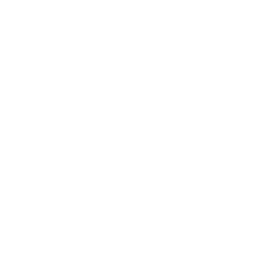
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrap-konfidensintervall för kliniska prövningsutfall</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Läkemedel / Klinisk biostatistik &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Detta genomarbetade exempel beräknar ett **icke-parametriskt bootstrap-konfidensintervall** för ett överlevnadsutfall med **PROC IML**, SAS matrisprogrammeringsspråk. Utfallet är **kvoten av mediandata för progressionsfri överlevnad (PFS)** mellan behandlings- och kontrollarmen i en liten tvåarmad onkologikohort.

IML-programmet läser in data på individnivå i matriser, beräknar den observerade median-PFS-kvoten, drar **2 000 bootstrap-omdragningar** med återläggning med hjälp av `CALL RANDGEN`, beräknar om kvoten för varje omdragning med matrisoperationer, och härleder ett **bias-korrigerat och accelererat (BCa)** konfidensintervall. BCa är det lämpliga valet här eftersom bootstrap-fördelningen för en kvot av medianer är nedåt begränsad av noll, diskret och sned — förhållanden under vilka ett vanligt normalfördelningsbaserat intervall är opålitligt.

Analysen körs helt inuti IML: bias-korrigeringskonstanten *z*<sub>0</sub>, accelerationen *a&#770;* från en leave-one-out-jackknife, och de justerade percentilgränserna sätts samman helt av matrisuttryck och standardnormalfunktionerna `PROBNORM` och en liten invers-normal-modul. Varje siffra som rapporteras nedan är hämtad direkt från IML-utdatan.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | PFS-tid, händelseindikator, behandlingsarm och baslinjekovariater per försöksperson | 100 |

Kohorten är **balanserad** — 50 försökspersoner per arm — genom att armtillhörighet tilldelas efter paritet på försökspersonens identifierare, så att båda armarna är fullt representerade i omdragningen.

---


In [1]:
/* --------------------------------------------------------
   Generera en syntetisk tvåarmad onkologikohort.
   PFS-tider är lognormala; behandlingsarmen är förskjuten
   till en längre median. Armtillhörighet alternerar på
   subject_id så att kohorten är balanserad 50/50.
   -------------------------------------------------------- */
data work.trial_subjects;
    CALL streaminit(42);
    GÖR subject_id = 1 TILL 500;
        /* 1 = Behandling, 0 = Kontroll (balanserad efter paritet) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'BEHANDLING', 'KONTROLL');
        /* PFS-tid i månader: behandlingsarmen har längre överlevnad */
        OM arm = 1 SÅ
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        ANNARS
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        OM pfs_months < 0.5 SÅ pfs_months = 0.5;
        /* Händelseindikator: ~75% av försökspersonerna hade en progressionshändelse */
        EVENT = (rand('uniform') > 0.25);
        /* Baslinjekovariater */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        OM AGE < 25 SÅ AGE = 25;
        OM AGE > 85 SÅ AGE = 85;
        UTDATA;
    SLUT;
KÖR;



NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---


                            Sammanfattning av progressionsfri överlevnad per behandlingsarm                             

                                                  The MEANS Procedure

                                     Analysis Variable : pfs_months PFS (månader)

        Behandlingsarm          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------------
        BEHANDLING                 50          13.94          10.10          11.95           2.70          79.10
        KONTROLL                   50          10.74           7.20           9.86           1.90          53.70
        --------------------------------------------------------------------------------------------------------

                                             Analysis Variable : AGE Ålder

        Behandlingsarm          N Obs           Mean         Median        Std Dev


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


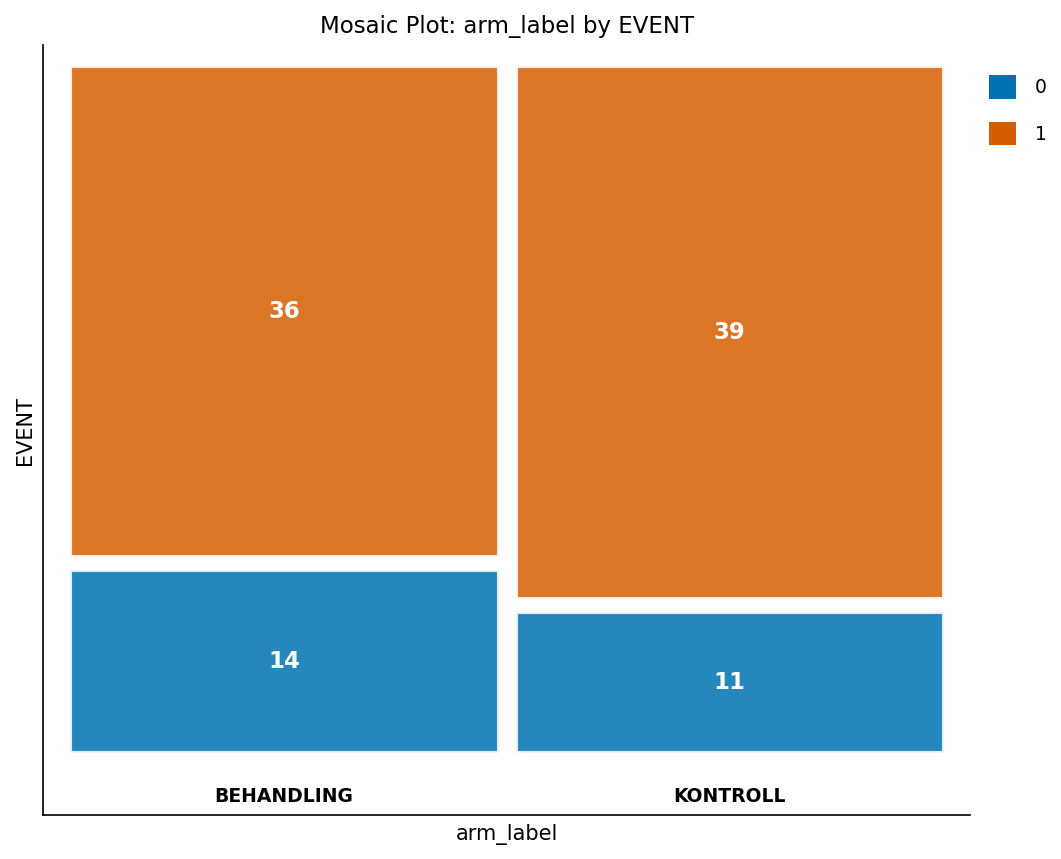

In [2]:
/* --------------------------------------------------------
   Baslinje-PFS-sammanfattning och händelsefrekvens per behandlingsarm
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    KLASS arm_label;
    VARIABEL pfs_months AGE;
    ETIKETT arm_label="Behandlingsarm" pfs_months="PFS (månader)" AGE="Ålder";
    TITEL 'Sammanfattning av progressionsfri överlevnad per behandlingsarm';
KÖR;

PROCEDUR FREKVENSER data=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    ETIKETT arm_label="Behandlingsarm" EVENT="Händelse";
    TITEL 'Antal händelser per behandlingsarm';
KÖR;


---


In [3]:
/* --------------------------------------------------------
   PROC IML: icke-parametrisk bootstrap för kvoten av
   median-PFS, med ett BCa-konfidensintervall.

   Steg:
   1. Läs in försöksdata i IML-matriser
   2. Beräkna den observerade median-PFS-kvoten (händelsetider)
   3. Dra 2 000 bootstrap-omdragningar med CALL RANDGEN
   4. Beräkna om kvoten för varje omdragning
   5. BCa-korrigering: z0 (bias) + jackknife-acceleration
   6. Skriv bootstrap-fördelningen till ett SAS-dataset
   -------------------------------------------------------- */
PROCEDUR IML;

    /* --- Modul: median-PFS per arm och deras kvot --- */
    /* Medianen beräknas endast över observerade händelsetider,
       den vanliga icke-parametriska sammanfattningen när de
       flesta försökspersoner progredierar. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        OM nrow(trt_pfs) = 0 SÅ trt_med = .;
        ANNARS trt_med = MEDIAN(trt_pfs);
        OM nrow(ctl_pfs) = 0 SÅ ctl_med = .;
        ANNARS ctl_med = MEDIAN(ctl_pfs);
        OM ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            SÅ RATIO = trt_med / ctl_med;
        ANNARS RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Modul: invers standardnormal-CDF (probit) --- */
    /* Rationell approximation (Abramowitz & Stegun 26.2.23);
       tillsammans med PROBNORM ger den de z0-/z-alfa-ändpunkter
       som BCa-justeringen behöver. */
    START probit(p);
        OM p <= 0 SÅ RETURN(-1e8);
        OM p >= 1 SÅ RETURN( 1e8);
        OM p < 0.5 SÅ GÖR; sgn = -1; pp = p;     SLUT;
        ANNARS            GÖR; sgn =  1; pp = 1 - p; SLUT;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Läs in data i matriser --- */
    USE work.trial_subjects;
        READ ALL VAR {pfs_months} INTO pfs;
        READ ALL VAR {arm}        INTO arm;
        READ ALL VAR {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    SKRIV 'Försökspersoner inlästa i IML', n n_trt n_ctl;

    /* --- 2. Observerad statistik på hela urvalet --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Behandling_Median Kontroll_Median Kvot};
    SKRIV 'Observerad median-PFS (händelsetider) per arm',
          obs[COLNAME=obs_lab format=8.3];

    /* --- 3. Bootstrap-omdragningsloop (2 000 omdragningar) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CALL randseed(2024);
    GÖR b = 1 TILL n_boot;
        CALL randgen(u, 'Uniform');     /* nya dragningar varje pass */
        idx = ceil(n # u);              /* index 1..n med återläggning */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    SLUT;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    CALL SORT(bv, 1);

    /* --- 4. Enkelt percentilintervall (för jämförelse) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. BCa-korrigering --- */
    /* z0: biaskorrigering från andelen omdragningar under
       den observerade statistikan. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat: acceleration från leave-one-out-jackknife. */
    jack = j(n, 1, .);
    GÖR i = 1 TILL n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    SLUT;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Justerade percentilpositioner. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Giltiga Andel_Under z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    SKRIV 'BCa-korrigeringsdiagnostik',
          diag[COLNAME=diag_lab format=8.4];

    ci_lab = {Obs_Kvot Pct_Lo Pct_Hi BCa_Lo BCa_Hi};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    SKRIV '95% KI för kvoten av median-PFS (behandling / kontroll)',
          ci_row[COLNAME=ci_lab format=8.4];

    /* --- 6. Spara bootstrap-fördelningen --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;


                                           Antal händelser per behandlingsarm                                           

Försökspersoner inlästa i IML
     100
      50
      50

Observerad median-PFS (händelsetider) per arm
   9.900   7.100   1.394

BCa-korrigeringsdiagnostik
2000.0000  0.5340  0.0851 -0.0021

95% KI för kvoten av median-PFS (behandling / kontroll)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  2.13 seconds
  cpu   2.13 seconds


---


In [4]:
/* --------------------------------------------------------
   Städa bootstrap-fördelningen inför plottning: ge
   kolumnerna beskrivande namn för histogrammet nedan.
   -------------------------------------------------------- */
data work.bootstrap_results;
    STÄLL_IN work.bootstrap_results
        (BYT_NAMN=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
KÖR;



NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---


                                           Antal händelser per behandlingsarm                                           




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


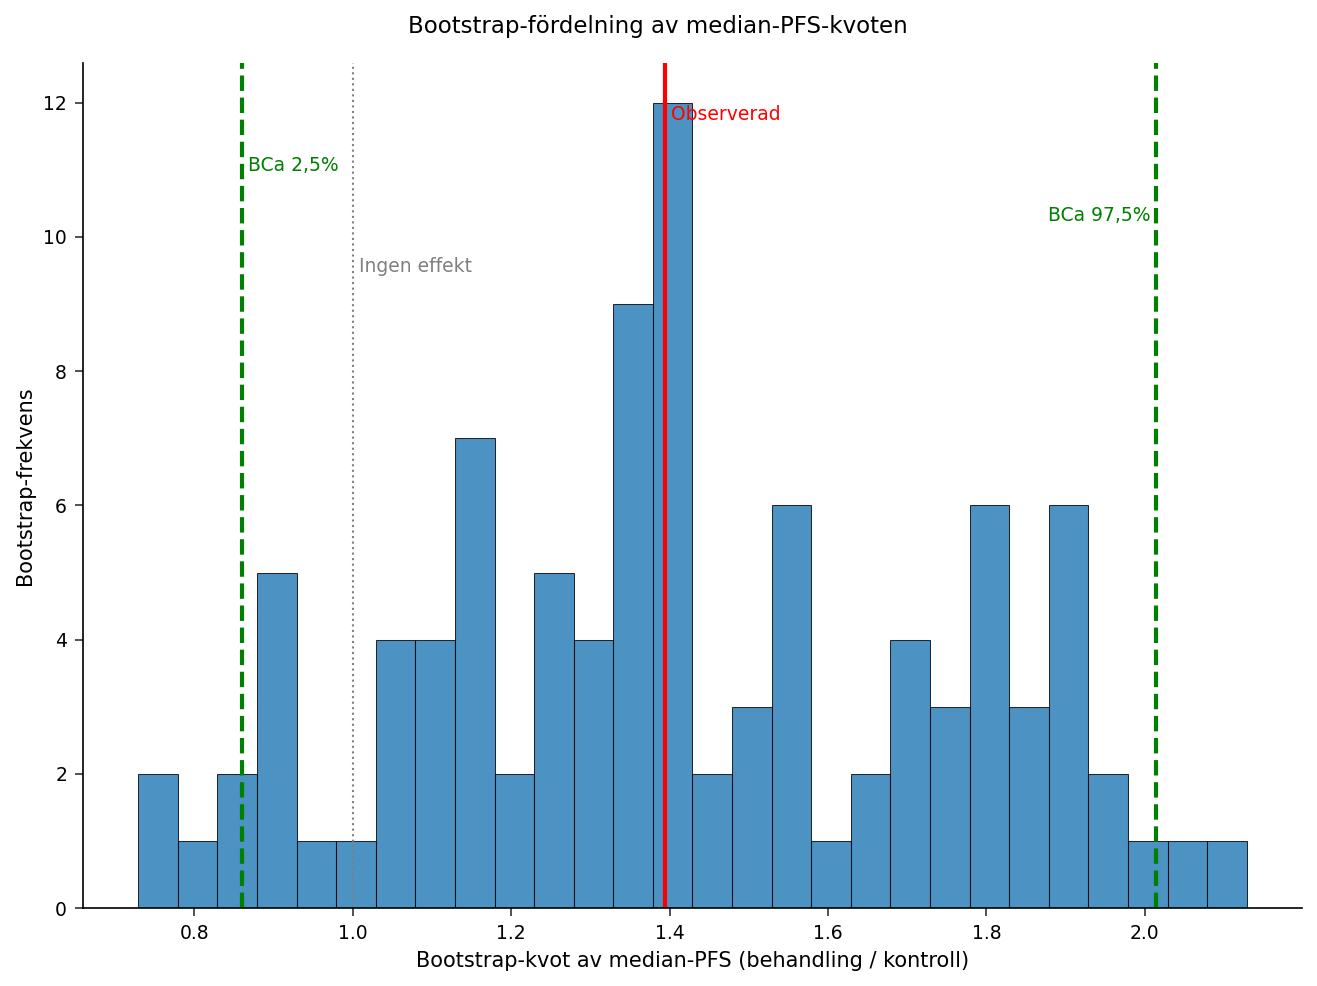

In [5]:
/* --------------------------------------------------------
   Bootstrap-fördelning av median-PFS-kvoten, med den
   observerade skattningen och BCa-intervallet markerade.
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) ETIKETT='Observerad';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ETIKETT='BCa 2,5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ETIKETT='BCa 97,5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        ETIKETT='Ingen effekt';
    XAXIS ETIKETT='Bootstrap-kvot av median-PFS (behandling / kontroll)';
    YAXIS ETIKETT='Bootstrap-frekvens';
    TITEL 'Bootstrap-fördelning av median-PFS-kvoten';
KÖR;


---


### Tolkning

I denna kohort är den observerade mediandata för PFS över händelsetider **9,9 månader** i behandlingsarmen och **7,1 månader** i kontrollarmen, en **kvot på 1,394** — den experimentella armens median-PFS är cirka 39 % längre. IML-programmet drog om de 100 försökspersonerna 2 000 gånger; samtliga 2 000 omdragningar gav en definierad kvot.

**BCa 95 %-konfidensintervallet för kvoten är [0,86, 2,01]**, jämfört med ett vanligt percentilintervall på **[0,82, 1,97]**. Båda intervallen **inkluderar 1,0**, så vid denna urvalsstorlek — ungefär 50 försökspersoner per arm, ytterligare uttunnad till observerade händelsetider — är den skenbara fördelen **inte statistiskt avgörande**. Detta är analysens ärliga budskap: en punktskattning som gynnar behandling, men med tillräcklig omdragningsosäkerhet för att en utebliven behandlingseffekt inte kan uteslutas.

BCa-diagnostiken kvantifierar hur mycket korrigeringen flyttade gränserna. Biastermen är liten (**z<sub>0</sub> = 0,085**: cirka 53 % av omdragningarna hamnade under den observerade kvoten, nära den symmetriska 50 %-nivån), och accelerationen är nära noll (**a&#770; = -0,002**), vilket visar att median-PFS-kvoten endast påverkas svagt av enskilda försökspersoner. Med både z<sub>0</sub> och a&#770; små förskjuter BCa intervallet bara något uppåt jämfört med percentilintervallet — exakt den måttliga korrigering dessa diagnoser förutspår.

En större studie skulle göra detta intervall smalare. Med 50 försökspersoner per arm rapporterar bootstrapmetoden korrekt att data är förenliga med allt från en liten omkastning till en fördubbling av median-PFS, vilket är anledningen till att en studie dimensionerad för att upptäcka en PFS-skillnad av denna storlek behöver betydligt fler än 100 försökspersoner.

---


In [6]:
/* --------------------------------------------------------
   Exportera bootstrap-fördelningen för en rapportbilaga.
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
KÖR;



NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>